<a href="https://colab.research.google.com/github/erdijova/Practical-Statistics-for-Data-Scientists/blob/main/Chapter_4_Regression_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4: Regression and Prediction (Comprehensive)

This notebook closely follows the structure and depth of *Practical Statistics for Data Scientists*.

We explore regression techniques for prediction and interpretation.

## Introduction

Regression is one of the most important tools in data science.

It is used for:
- Predicting numerical outcomes
- Understanding relationships between variables
- Modeling real-world systems

This chapter covers both theory and implementation.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## Load Dataset

We use a sample dataset for regression tasks.

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv')
df = df.sample(1000, random_state=42)
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
1388,0.24,Ideal,G,VVS1,62.1,56.0,559,3.97,4.00,2.47
50052,0.58,Very Good,F,VVS2,60.0,57.0,2201,5.44,5.42,3.26
41645,0.40,Ideal,E,VVS2,62.1,55.0,1238,4.76,4.74,2.95
42377,0.43,Premium,E,VVS2,60.8,57.0,1304,4.92,4.89,2.98
17244,1.55,Ideal,E,SI2,62.3,55.0,6901,7.44,7.37,4.61


## Simple Linear Regression

A simple linear regression models the relationship between one predictor (X) and one response (y).

Model:
y = β0 + β1X

Where:
- β0 = intercept
- β1 = slope

In [3]:
X = df[['carat']]
y = df['price']

model = LinearRegression()
model.fit(X, y)

print('Intercept:', model.intercept_)
print('Slope:', model.coef_)

Intercept: -2408.0859936650477
Slope: [7943.48398026]


## Visualization of Regression Line

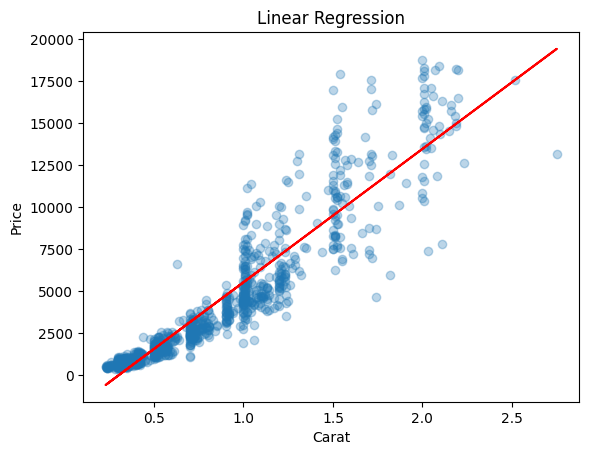

In [4]:
plt.scatter(X, y, alpha=0.3)
plt.plot(X, model.predict(X), color='red')
plt.xlabel('Carat')
plt.ylabel('Price')
plt.title('Linear Regression')
plt.show()

## Residuals

Residual = Actual - Predicted

Residuals help evaluate model performance.

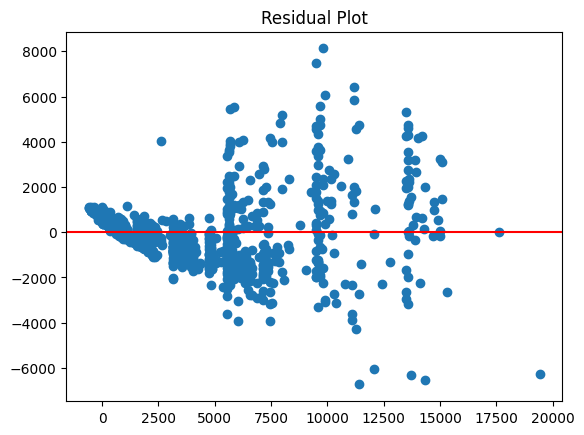

In [5]:
pred = model.predict(X)
residuals = y - pred

plt.scatter(pred, residuals)
plt.axhline(0, color='red')
plt.title('Residual Plot')
plt.show()

## Multiple Linear Regression

Uses multiple predictors.

y = β0 + β1X1 + β2X2 + ...

In [6]:
X_multi = df[['carat','depth','table']]
y = df['price']

model_multi = LinearRegression()
model_multi.fit(X_multi, y)

model_multi.coef_

array([8005.98931693, -105.1234716 ,  -91.3848442 ])

## Train-Test Split

Used to evaluate model performance on unseen data.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

model_multi.fit(X_train, y_train)
preds = model_multi.predict(X_test)

print('RMSE:', np.sqrt(mean_squared_error(y_test, preds)))

RMSE: 1733.43002762623


## Overfitting and Underfitting

- Overfitting: model learns noise
- Underfitting: model too simple

Goal: balance bias and variance.

## Correlated Predictors (Multicollinearity)

Highly correlated predictors can distort regression coefficients.

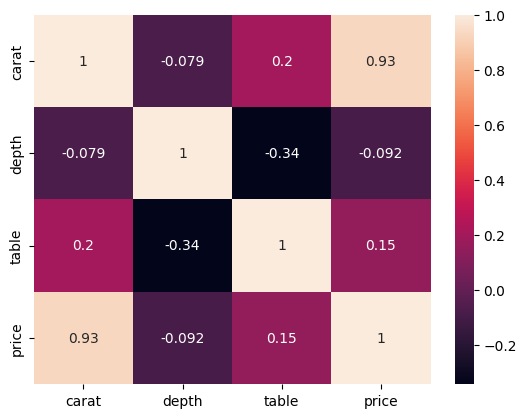

In [8]:
sns.heatmap(df[['carat','depth','table','price']].corr(), annot=True)
plt.show()

## Nonlinear Relationships (Polynomial Regression)

Linear regression can be extended using polynomial features.

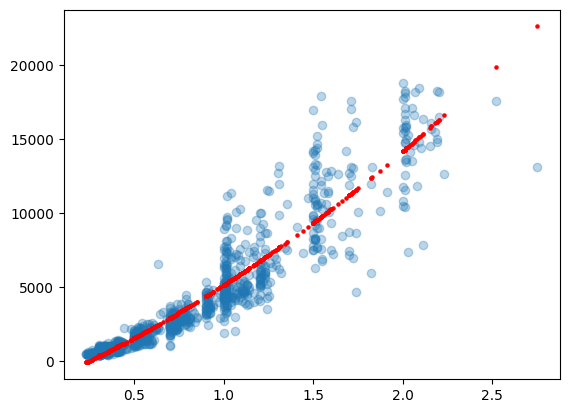

In [9]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model_poly = LinearRegression()
model_poly.fit(X_poly, y)

pred_poly = model_poly.predict(X_poly)

plt.scatter(X, y, alpha=0.3)
plt.scatter(X, pred_poly, color='red', s=5)
plt.show()

## Prediction vs Explanation

- Prediction focuses on accuracy
- Explanation focuses on understanding relationships

These goals can sometimes conflict.

## Conclusion

In this chapter, we covered:
- Simple and multiple regression
- Model evaluation
- Residual analysis
- Overfitting
- Multicollinearity
- Nonlinear regression

Regression is a core technique in predictive modeling.